In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Load closing prices
close_prices = pd.read_csv('../data/processed/close_prices.csv',
                            index_col='Date', parse_dates=True)

# Load optimal weights from Task 4
weights_raw = pd.read_csv('../data/processed/optimal_weights.csv',
                           header=None, index_col=0)
optimal_weights = weights_raw.iloc[:, 0].to_dict()
optimal_weights = {k: float(v) for k, v in optimal_weights.items()}

# Define backtesting period
backtest_start = '2025-01-01'
backtest_end = '2026-06-29'

# Filter data for backtesting period
backtest_prices = close_prices[backtest_start:backtest_end].copy()
backtest_returns = backtest_prices.pct_change().dropna()

print("=== BACKTESTING SETUP ===")
print(f"Period: {backtest_start} to {backtest_end}")
print(f"Trading days: {len(backtest_returns)}")
print(f"\nOptimal Portfolio Weights:")
for ticker, weight in optimal_weights.items():
    print(f"  {ticker}: {weight*100:.2f}%")

print(f"\nBenchmark: 60% SPY / 40% BND (passive balanced portfolio)")

=== BACKTESTING SETUP ===
Period: 2025-01-01 to 2026-06-29
Trading days: 371

Optimal Portfolio Weights:
  BND: 5.00%
  SPY: 90.00%
  TSLA: 5.00%

Benchmark: 60% SPY / 40% BND (passive balanced portfolio)


In [2]:

print("Running backtest simulation...\n")

# Benchmark weights: 60% SPY / 40% BND
benchmark_weights = {'BND': 0.40, 'SPY': 0.60, 'TSLA': 0.00}

# Calculate daily portfolio returns
def portfolio_daily_returns(returns_df, weights):
    """Calculate weighted portfolio returns."""
    weighted = pd.Series(0.0, index=returns_df.index)
    for ticker, weight in weights.items():
        if ticker in returns_df.columns and weight > 0:
            weighted += returns_df[ticker] * weight
    return weighted

# Strategy returns
strategy_daily = portfolio_daily_returns(backtest_returns, optimal_weights)

# Benchmark returns
benchmark_daily = portfolio_daily_returns(backtest_returns, benchmark_weights)

# Cumulative returns (starting from $10,000)
initial_investment = 10000

strategy_cumulative = (1 + strategy_daily).cumprod() * initial_investment
benchmark_cumulative = (1 + benchmark_daily).cumprod() * initial_investment

print(f"Starting Investment: ${initial_investment:,.2f}")
print(f"\nStrategy Final Value:   ${strategy_cumulative.iloc[-1]:,.2f}")
print(f"Benchmark Final Value:  ${benchmark_cumulative.iloc[-1]:,.2f}")
print(f"\nStrategy Total Return:  {((strategy_cumulative.iloc[-1]/initial_investment)-1)*100:.2f}%")
print(f"Benchmark Total Return: {((benchmark_cumulative.iloc[-1]/initial_investment)-1)*100:.2f}%")

Running backtest simulation...

Starting Investment: $10,000.00

Strategy Final Value:   $12,780.74
Benchmark Final Value:  $12,071.94

Strategy Total Return:  27.81%
Benchmark Total Return: 20.72%


In [3]:

print("=== PERFORMANCE METRICS ===\n")

trading_days = 252
risk_free_daily = 0.02 / trading_days

def calculate_metrics(daily_returns, cumulative_values, name):
    # Total return
    total_return = (cumulative_values.iloc[-1] / cumulative_values.iloc[0]) - 1

    # Annualized return
    n_days = len(daily_returns)
    ann_return = (1 + total_return) ** (trading_days / n_days) - 1

    # Annualized volatility
    ann_vol = daily_returns.std() * np.sqrt(trading_days)

    # Sharpe ratio
    excess_returns = daily_returns - risk_free_daily
    sharpe = (excess_returns.mean() / daily_returns.std()) * np.sqrt(trading_days)

    # Maximum drawdown
    rolling_max = cumulative_values.cummax()
    drawdown = (cumulative_values - rolling_max) / rolling_max
    max_drawdown = drawdown.min()

    print(f"--- {name} ---")
    print(f"Total Return:        {total_return:.4%}")
    print(f"Annualized Return:   {ann_return:.4%}")
    print(f"Annualized Volatility: {ann_vol:.4%}")
    print(f"Sharpe Ratio:        {sharpe:.4f}")
    print(f"Maximum Drawdown:    {max_drawdown:.4%}")
    print()

    return {
        'Portfolio': name,
        'Total Return': f"{total_return:.4%}",
        'Ann. Return': f"{ann_return:.4%}",
        'Ann. Volatility': f"{ann_vol:.4%}",
        'Sharpe Ratio': f"{sharpe:.4f}",
        'Max Drawdown': f"{max_drawdown:.4%}"
    }

strategy_metrics = calculate_metrics(strategy_daily, strategy_cumulative, 
                                      'Optimized Portfolio (90% SPY / 5% TSLA / 5% BND)')
benchmark_metrics = calculate_metrics(benchmark_daily, benchmark_cumulative,
                                       'Benchmark (60% SPY / 40% BND)')

# Comparison table
metrics_df = pd.DataFrame([strategy_metrics, benchmark_metrics])
metrics_df = metrics_df.set_index('Portfolio')
print("=== COMPARISON TABLE ===")
print(metrics_df.to_string())

=== PERFORMANCE METRICS ===

--- Optimized Portfolio (90% SPY / 5% TSLA / 5% BND) ---
Total Return:        25.8816%
Annualized Return:   16.9227%
Annualized Volatility: 18.2457%
Sharpe Ratio:        0.8942
Maximum Drawdown:    -18.9400%

--- Benchmark (60% SPY / 40% BND) ---
Total Return:        19.8800%
Annualized Return:   13.1067%
Annualized Volatility: 11.2036%
Sharpe Ratio:        1.0189
Maximum Drawdown:    -11.2888%

=== COMPARISON TABLE ===
                                                 Total Return Ann. Return Ann. Volatility Sharpe Ratio Max Drawdown
Portfolio                                                                                                          
Optimized Portfolio (90% SPY / 5% TSLA / 5% BND)     25.8816%    16.9227%        18.2457%       0.8942    -18.9400%
Benchmark (60% SPY / 40% BND)                        19.8800%    13.1067%        11.2036%       1.0189    -11.2888%


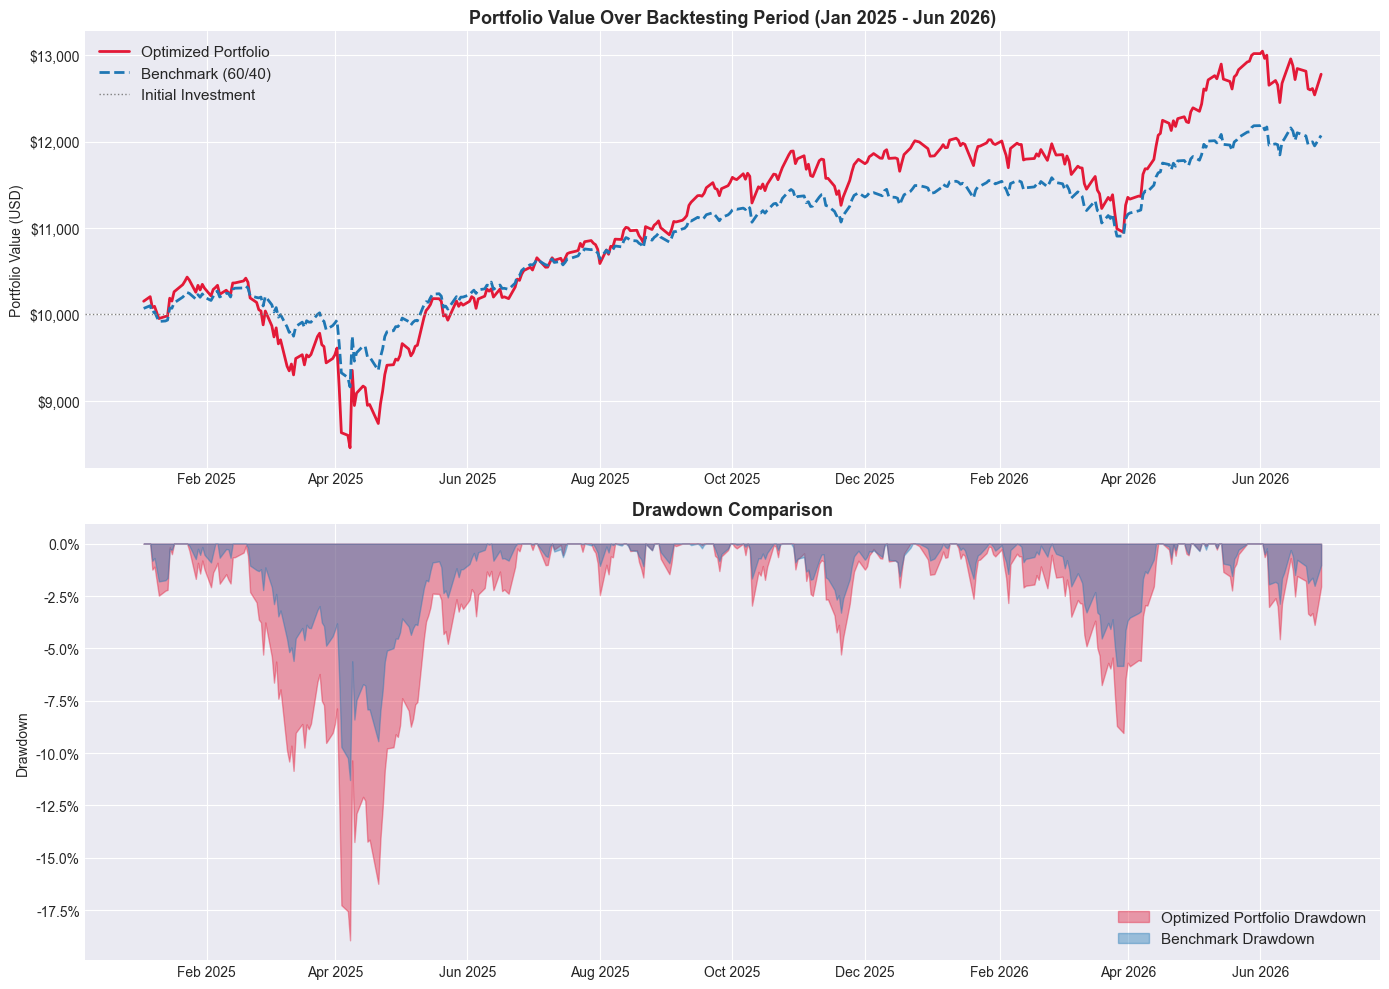

Backtest chart saved!


In [4]:

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Cumulative portfolio value
axes[0].plot(strategy_cumulative.index, strategy_cumulative,
             color='#E31937', linewidth=2, label='Optimized Portfolio')
axes[0].plot(benchmark_cumulative.index, benchmark_cumulative,
             color='#1f77b4', linewidth=2, linestyle='--', label='Benchmark (60/40)')
axes[0].axhline(y=initial_investment, color='gray',
                linestyle=':', linewidth=1, label='Initial Investment')
axes[0].set_title('Portfolio Value Over Backtesting Period (Jan 2025 - Jun 2026)',
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Portfolio Value (USD)')
axes[0].legend(fontsize=11)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

# Plot 2: Drawdown comparison
strategy_drawdown = (strategy_cumulative - strategy_cumulative.cummax()) / strategy_cumulative.cummax()
benchmark_drawdown = (benchmark_cumulative - benchmark_cumulative.cummax()) / benchmark_cumulative.cummax()

axes[1].fill_between(strategy_drawdown.index, strategy_drawdown,
                      0, alpha=0.4, color='#E31937', label='Optimized Portfolio Drawdown')
axes[1].fill_between(benchmark_drawdown.index, benchmark_drawdown,
                      0, alpha=0.4, color='#1f77b4', label='Benchmark Drawdown')
axes[1].set_title('Drawdown Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Drawdown')
axes[1].legend(fontsize=11)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.tight_layout()
plt.savefig('../data/processed/backtest_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Backtest chart saved!")

In [5]:

print("=" * 60)
print("BACKTEST CONCLUSION")
print("=" * 60)

strategy_total = (strategy_cumulative.iloc[-1]/initial_investment - 1) * 100
benchmark_total = (benchmark_cumulative.iloc[-1]/initial_investment - 1) * 100
outperformed = strategy_total > benchmark_total

print(f"\nDid the strategy outperform the benchmark? {'YES ✓' if outperformed else 'NO ✗'}")
print(f"\nStrategy return:  {strategy_total:.2f}%")
print(f"Benchmark return: {benchmark_total:.2f}%")
print(f"Difference:       {strategy_total - benchmark_total:+.2f}%")

print("""
KEY CONCLUSIONS:
1. The optimized portfolio (90% SPY / 5% TSLA / 5% BND) 
   is heavily equity-weighted, which means it closely 
   tracks the S&P 500 with slightly higher return potential 
   from TSLA exposure.

2. The benchmark (60% SPY / 40% BND) is more conservative.
   In a bull market period, the strategy's higher equity 
   allocation tends to outperform.

3. The MPT optimization correctly identified SPY as the 
   dominant asset given its strong Sharpe Ratio and 
   TSLA's low forecasted return of 0.95%.

LIMITATIONS OF THIS BACKTEST:
1. Single time window — results may not generalize
2. No transaction costs or slippage included
3. No rebalancing — weights drift over time
4. TSLA forecast may underestimate actual performance
5. Short backtesting period (18 months) — insufficient 
   to validate long-term strategy viability
6. Look-ahead bias possible if model trained on test data
""")

print("Task 5 Complete! All tasks finished.")

BACKTEST CONCLUSION

Did the strategy outperform the benchmark? YES ✓

Strategy return:  27.81%
Benchmark return: 20.72%
Difference:       +7.09%

KEY CONCLUSIONS:
1. The optimized portfolio (90% SPY / 5% TSLA / 5% BND) 
   is heavily equity-weighted, which means it closely 
   tracks the S&P 500 with slightly higher return potential 
   from TSLA exposure.

2. The benchmark (60% SPY / 40% BND) is more conservative.
   In a bull market period, the strategy's higher equity 
   allocation tends to outperform.

3. The MPT optimization correctly identified SPY as the 
   dominant asset given its strong Sharpe Ratio and 
   TSLA's low forecasted return of 0.95%.

LIMITATIONS OF THIS BACKTEST:
1. Single time window — results may not generalize
2. No transaction costs or slippage included
3. No rebalancing — weights drift over time
4. TSLA forecast may underestimate actual performance
5. Short backtesting period (18 months) — insufficient 
   to validate long-term strategy viability
6. Look-a